In [1]:
# 모듈 및 데이터 로드
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()

# x, y 데이터 생성
X = data.data

# 악성을 1, 양성을 0으로
y = 1 - data.target

# 특징으로 사용할 데이터를 평균으로 구분하는 10개 열로 축소
X = X[:, :10]

# 로지스틱 회귀 모델 생성
model_lor = LogisticRegression(solver = 'lbfgs')
model_lor.fit(X,y)
y_pred = model_lor.predict(X)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**오차 행렬(혼동 행렬) 생성**

In [2]:
from sklearn.metrics import confusion_matrix

# 종속 변수(y)와 예측 결과(y_pred)로 혼동 행렬 생성
cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[337  20]
 [ 30 182]]


**정확도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [3]:
#정확도 : 전체 예측 건수 중 올바르게 예측한 비율
#알 수 있는 점: 전체 데이터 중 모델이 악성/양성 여부를 올바르게 분류한 전반적인 성능 수치를 확인

from sklearn.metrics import accuracy_score

acc = accuracy_score(y, y_pred)
print(f"정확도: {acc:.4f}")

정확도: 0.9121


**정밀도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [4]:
#정밀도 개념:모델이 악성(1)이라고 예측한 것 중 실제 악성(1)인 비율
#알 수 있는 점:모델이 악성(양성 반응)이라고 판단했을 때, 그 예측이 얼마나 신뢰할 수 있는지 (False Positive를 줄이는 성능 판단)

from sklearn.metrics import precision_score

prec = precision_score(y, y_pred)
print(f"정밀도: {prec:.4f}")

정밀도: 0.9010


**재현율의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [5]:
#재현율: 실제 악성(1)인 데이터 중 모델이 악성(1)이라고 정확히 맞춘 비율
#알 수 있는 점:실제 암 환자(악성)를 놓치지 않고 얼마나 잘 찾아내는지 

from sklearn.metrics import recall_score

rec = recall_score(y, y_pred)
print(f"재현율: {rec:.4f}")

재현율: 0.8585


**F1 score의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [6]:
#개념:정밀도와 재현율의 조화평균으로, 두 지표가 균형을 이루는지 평가하는 수치
#알 수 있는 점:정밀도와 재현율 중 어느 한쪽에 치우치지 않고 모델이 균형 있게 잘 예측하고 있는지를 평가

from sklearn.metrics import f1_score

f1 = f1_score(y, y_pred)
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.8792


**예측 확률(pred_proba) : 0으로 예측할 확률이 0.1보다 크면 y_pred2 에 넣는다 가정.**

In [7]:
from sklearn.preprocessing import Binarizer


In [8]:
# y과 y_pred2의 혼동행렬, 정확도, 정밀도, 재현율, f1 score 구하기


# 예측 확률 추출 (1열: 악성(1)일 확률)
pred_proba_1 = model_lor.predict_proba(X)[:, 1].reshape(-1, 1)

# 임계값 0.9 설정 (1일 확률이 0.9 이상이면 1, 아니면 0 -> 즉, 0일 확률이 0.1 이하일 때만 1)
binarizer = Binarizer(threshold=0.9)
y_pred2 = binarizer.fit_transform(pred_proba_1)

# 혼동 행렬 및 평가지표 출력
print("Confusion Matrix:\n", confusion_matrix(y, y_pred2))
print(f"정확도: {accuracy_score(y, y_pred2):.4f}")
print(f"정밀도: {precision_score(y, y_pred2):.4f}")
print(f"재현율: {recall_score(y, y_pred2):.4f}")
print(f"F1 Score: {f1_score(y, y_pred2):.4f}")


Confusion Matrix:
 [[356   1]
 [ 73 139]]
정확도: 0.8699
정밀도: 0.9929
재현율: 0.6557
F1 Score: 0.7898


**ROC 곡선 시각화**

In [9]:
from sklearn.metrics import roc_curve


In [10]:
import matplotlib.pyplot as plt


**ROC AUC 값을 구하고 해당 값을 통해 알 수 있는 점을 쓰시오.**

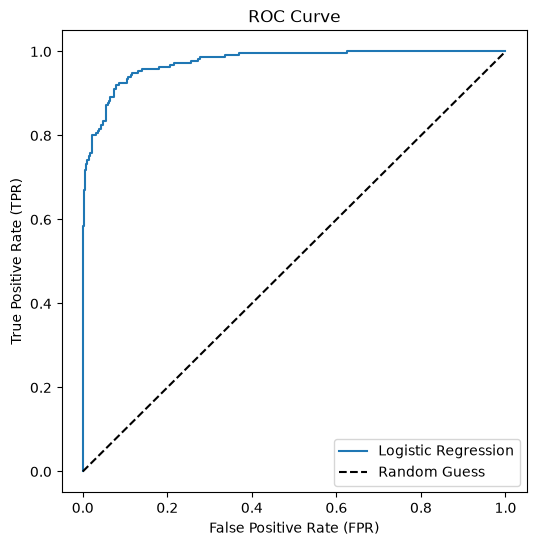

In [11]:
fpr, tpr, thresholds = roc_curve(y, pred_proba_1)

# 시각화
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend()
plt.show()


#알 수 있는 점: ROC 곡선 아래의 면적인 AUC 수치(1에 가까울수록 우수)를 통해,
#다양한 임계값 조건에서도 모델이 전반적으로 악성과 양성을 구분해내는 성능이 얼마나 뛰어난지 알 수 있음